# Part A — Transfer Learning on Food101

**Assignment 2 · Computer Vision**

This notebook implements **transfer learning** using three pre-trained CNN architectures on the [Food101 dataset](http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz):

| Model | Year | Key Innovation |
|---|---|---|
| GoogLeNet (Inception v1) | 2014 | Inception modules — parallel conv branches |
| MobileNet V3 | 2019 | Depthwise separable convs + SE blocks — mobile-friendly |
| ResNet-50 | 2015 | Residual skip connections — solves vanishing gradient |

**Strategy for each model:**
1. Load ImageNet pre-trained weights
2. Freeze all pre-trained layers
3. Replace the classification head with 3 fully-connected layers
4. Train only the new head on Food101
5. Evaluate and compare performance

---

## 0 · Imports & Configuration

In [89]:
# ── 1. Environment Setup & Dependencies ────────────────────────────────────────
import os
import sys
import shutil
import subprocess
import zipfile
from pathlib import Path

# Identify environment
IN_COLAB = 'google.colab' in sys.modules

# Define where the source zip is located on your Drive
GDRIVE_ZIP_PATH = Path("/content/drive/MyDrive/UTS/Semestre 2/Deep Learning/Assignment_2/food-101.zip")

# Checkpoints are persisted to Drive so they survive Colab session resets
GDRIVE_CHECKPOINT_DIR = Path("/content/drive/MyDrive/UTS/Semestre 2/Deep Learning/Assignment_2/checkpoints")

try:
    if IN_COLAB:
        from google.colab import drive  # type: ignore
        drive.mount("/content/drive", force_remount=False)
        
        print("Google Drive mounted. Checking/Installing pytorch-ignite...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "pytorch-ignite", "-q"])
        
        # In Colab, we work out of the local /content directory for maximum IO speed
        BASE_DIR = Path("/content")
        print(f"Running in Colab — Base Directory: {BASE_DIR}")
    else:
        BASE_DIR = Path(".")
        print(f"Google Colab not detected — using local path: {BASE_DIR}")
        
except Exception as e:
    BASE_DIR = Path(".")
    print(f"Environment setup warning ({e}) — using local path: {BASE_DIR}")


# ── 2. Imports ─────────────────────────────────────────────────────────────────
import json
import random
import time
from collections import Counter

# Third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
from sklearn.dummy import DummyClassifier

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import ConcatDataset, DataLoader, Subset, random_split
from torchvision import datasets, models, transforms

# Ignite
try:
    from ignite.engine import Engine, Events
    from ignite.handlers import EarlyStopping
    from ignite.metrics import Accuracy, Loss as IgniteLoss
    from ignite.contrib.handlers import ProgressBar
except ImportError:
    print("Warning: pytorch-ignite not found. Ensure it is installed via pip.")


# ── 3. Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ── 4. Hyperparameters & Configuration ─────────────────────────────────────────
NUM_CLASSES   = 101
BATCH_SIZE    = 64    
NUM_EPOCHS    = 12
LEARNING_RATE = 0.0015
IMG_SIZE      = 224
DATA_FRACTION = 1.0 
VAL_FRACTION  = 0.15    


# ── 5. Hardware Setup ──────────────────────────────────────────────────────────
DEVICE = (
    torch.device("cuda") if torch.cuda.is_available() else
    torch.device("mps")  if torch.backends.mps.is_available() else
    torch.device("cpu")
)
print(f"Using device: {DEVICE}")

if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True


# ── 6. Directory Setup & Data Copying (Colab Optimization) ─────────────────────
DATA_DIR       = BASE_DIR / "data/food-101"
IMG_DIR        = DATA_DIR / "images"
META_DIR       = DATA_DIR / "meta"

# In Colab: checkpoints are saved directly to Google Drive so they persist across
# session resets. Locally: stored relative to the notebook directory.
if IN_COLAB:
    CHECKPOINT_DIR = GDRIVE_CHECKPOINT_DIR
else:
    CHECKPOINT_DIR = BASE_DIR / "checkpoints"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Checkpoint directory: {CHECKPOINT_DIR}")

# Copy and Unzip logic for Colab
if IN_COLAB and not DATA_DIR.exists():
    LOCAL_ZIP = Path("/content/food-101.zip")
    
    if GDRIVE_ZIP_PATH.exists():
        # Ensure the /content/data directory exists
        (BASE_DIR / "data").mkdir(parents=True, exist_ok=True)
        
        print(f"Copying zip from Drive to {LOCAL_ZIP}...")
        shutil.copy(GDRIVE_ZIP_PATH, LOCAL_ZIP)
        
        print(f"Unzipping dataset to {BASE_DIR / 'data'}...")
        # Unzipping into /content/data creates /content/data/food-101
        with zipfile.ZipFile(LOCAL_ZIP, 'r') as zip_ref:
            zip_ref.extractall(BASE_DIR / "data")
        
        # Cleanup: Remove zip file after extraction to save disk space
        LOCAL_ZIP.unlink()
        print("Extraction complete and zip removed.")
    else:
        print(f"ERROR: Zip file not found at {GDRIVE_ZIP_PATH}. Check your Drive path!")

print(f"DATA_DIR is set to: {DATA_DIR}")

Google Colab not detected — using local path: .
Using device: mps
Checkpoint directory: checkpoints
DATA_DIR is set to: data/food-101


## 0. Utils

In [90]:
class TrainingVisualizer:
    """Plotting utilities for transfer learning experiments."""

    _PALETTE = {
        "GoogLeNet":   "royalblue",
        "MobileNetV3": "mediumseagreen",
        "ResNet-50":   "tomato",
    }
    _TRAIN_COLOR = "steelblue"
    _VAL_COLOR   = "darkorange"

    # ── Dataset distribution (Optimized & Stacked) ─────────────────────────────

    def _get_labels_from_dataset(self, dataset):
        """Recursively unwraps Subsets and ConcatDatasets to extract labels instantly."""
        from torch.utils.data import Subset, ConcatDataset
        
        if isinstance(dataset, Subset):
            base_labels = self._get_labels_from_dataset(dataset.dataset)
            return [base_labels[i] for i in dataset.indices]
            
        elif isinstance(dataset, ConcatDataset):
            labels = []
            for ds in dataset.datasets:
                labels.extend(self._get_labels_from_dataset(ds))
            return labels
            
        else:
            # Base dataset: find the label attribute (Food101 uses _labels, ImageFolder uses targets)
            if hasattr(dataset, 'targets'):
                return dataset.targets
            elif hasattr(dataset, '_labels'):
                return dataset._labels
            elif hasattr(dataset, 'labels'):
                return dataset.labels
            else:
                # Fallback: if no label attribute exists, we MUST iterate (slow)
                print("Warning: No target attribute found. Falling back to slow iteration.")
                return [dataset[i][1] for i in range(len(dataset))]

    def plot_class_distribution(self, datasets_dict: dict, class_names: list = None, figsize_per_row: tuple = (16, 4)) -> None:
        """
        Plot the class distribution across multiple datasets as separate subplots.
        
        Parameters
        ----------
        datasets_dict : dict
            Dictionary mapping dataset names to Dataset objects (e.g., {"Train": train_dataset, "Val": val_dataset}).
        class_names : list, optional
            List of string class names. If None, numeric indices are used.
        figsize_per_row : tuple
            The figure size for *each* individual subplot.
        """
        counts_dict = {}
        
        # 1. Gather counts instantly using the unwrapping helper
        for name, dataset in datasets_dict.items():
            labels = self._get_labels_from_dataset(dataset)
            if torch.is_tensor(labels[0]):
                labels = [l.item() for l in labels]
            counts_dict[name] = Counter(labels)

        # 2. Get all unique classes across all datasets
        all_classes_idx = set()
        for counter in counts_dict.values():
            all_classes_idx.update(counter.keys())
        all_classes_idx = sorted(list(all_classes_idx))

        # 3. Resolve x-axis labels
        if class_names and len(class_names) >= len(all_classes_idx):
            labels_shown = [class_names[i].replace("_", " ") for i in all_classes_idx]
        else:
            labels_shown = [str(i) for i in all_classes_idx]

        # 4. Prepare plot parameters
        x = np.arange(len(all_classes_idx))
        n_splits = len(datasets_dict)
        split_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

        # Create vertically stacked subplots
        fig, axes = plt.subplots(n_splits, 1, figsize=(figsize_per_row[0], figsize_per_row[1] * n_splits))
        if n_splits == 1:
            axes = [axes]

        # 5. Plot individual bar charts
        for i, ((name, counter), ax) in enumerate(zip(counts_dict.items(), axes)):
            vals = [counter.get(c, 0) for c in all_classes_idx]
            
            # Plot the bars
            ax.bar(x, vals, width=0.8, color=split_colors[i % len(split_colors)])
            
            # Formatting for each subplot
            ax.set_ylabel("Samples", fontsize=12)
            ax.set_title(f"{name} Dataset", fontsize=14, fontweight="bold")
            ax.set_xticks(x)
            
            # To avoid severe clutter with 101 classes, only show the x-axis text on the bottom plot
            if i == n_splits - 1:
                rotation = 90 if class_names else 0  # 90 degrees is perfect for 101 names
                ax.set_xticklabels(labels_shown, rotation=rotation, ha="center", fontsize=8)
                ax.set_xlabel("Class Label", fontsize=12)
            else:
                ax.set_xticklabels([]) # Hide text for upper plots
            
            # Margins and grid
            ax.margins(x=0.01) # Tighter margins on the left/right
            ax.set_axisbelow(True)
            ax.yaxis.grid(True, linestyle="--", alpha=0.7)

        fig.suptitle("Class Distribution per Dataset", fontsize=16, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.show()

    # ── Per-model train/val curves ─────────────────────────────────────────────

    def plot_loss(self, histories: dict, figsize_per: tuple = (6, 4)) -> None:
        """Train vs validation loss curve for each model."""
        self._plot_metric(histories, metric="loss", ylabel="Cross-Entropy Loss",
                          title="Training vs Validation Loss", figsize_per=figsize_per)

    def plot_accuracy(self, histories: dict, figsize_per: tuple = (6, 4)) -> None:
        """Train vs validation accuracy curve for each model."""
        self._plot_metric(histories, metric="acc", ylabel="Accuracy",
                          title="Training vs Validation Accuracy", figsize_per=figsize_per)

    def _plot_metric(self, histories: dict, metric: str, ylabel: str,
                     title: str, figsize_per: tuple) -> None:
        n = len(histories)
        fig, axes = plt.subplots(1, n, figsize=(figsize_per[0] * n, figsize_per[1]), sharey=True)
        if n == 1:
            axes = [axes]

        for ax, (name, hist) in zip(axes, histories.items()):
            epochs = range(1, len(hist[f"train_{metric}"]) + 1)
            ax.plot(epochs, hist[f"train_{metric}"], label="Train",
                    color=self._TRAIN_COLOR, marker="o", ms=4)
            ax.plot(epochs, hist[f"val_{metric}"], label="Val",
                    color=self._VAL_COLOR, marker="s", ms=4)
            ax.set_title(name, fontsize=12)
            ax.set_xlabel("Epoch")
            ax.set_ylabel(ylabel)
            ax.legend()
            ax.grid(True, linestyle="--", alpha=0.5)

        plt.suptitle(title, fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.show()

    # ── Test set results ───────────────────────────────────────────────────────

    def plot_test_loss(self, results: dict) -> None:
        """Bar chart of test loss for each model (skips entries with None loss)."""
        filtered = {k: v for k, v in results.items() if v.get("test_loss") is not None}
        names  = list(filtered.keys())
        losses = [filtered[m]["test_loss"] for m in names]
        colours = [self._PALETTE.get(m, "slategray") for m in names]

        fig, ax = plt.subplots(figsize=(8, 4))
        bars = ax.bar(names, losses, color=colours, edgecolor="white", linewidth=1.2)
        ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=11)
        ax.set_ylabel("Cross-Entropy Loss", fontsize=12)
        ax.set_title("Test Loss per Model", fontsize=14, fontweight="bold")
        ax.grid(True, axis="y", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

    def plot_test_accuracy(self, results: dict) -> None:
        """Bar chart of test accuracy for each model."""
        names  = list(results.keys())
        accs   = [results[m]["test_acc"] for m in names]
        colours = [self._PALETTE.get(m, "slategray") for m in names]

        fig, ax = plt.subplots(figsize=(10, 5))
        bars = ax.bar(names, accs, color=colours, edgecolor="white", linewidth=1.2)
        ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=11)
        ax.set_ylim(0, 1.0)
        ax.set_ylabel("Test Accuracy", fontsize=12)
        ax.set_title("Test Accuracy per Model", fontsize=14, fontweight="bold")
        ax.grid(True, axis="y", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

    # ── Confusion matrix ───────────────────────────────────────────────────────

    def plot_confusion_matrix(self, model: "nn.Module", loader, class_names: list,
                               top_n: int = 20, figsize: tuple = (14, 12), device: str = "cuda") -> None:
        """
        Compute and display two confusion matrices for *model* on *loader*:
        one for the top_n most-confused classes and one for the top_n least-confused classes.

        Parameters
        ----------
        top_n : int
            Number of classes to show in each plot.
        device: str
            Preferred device ("cuda", "mps", or "cpu"). Falls back automatically
            if the requested device is unavailable (MPS on Apple Silicon, CPU elsewhere).
        """
        from sklearn.metrics import confusion_matrix

        # ── Auto-detect device ────────────────────────────────────────────────
        if device == "cuda" and not torch.cuda.is_available():
            if torch.backends.mps.is_available():
                device = "mps"
            else:
                device = "cpu"
        elif device == "mps" and not torch.backends.mps.is_available():
            device = "cpu"
        device = torch.device(device)
        model = model.to(device)

        # ── Inference ─────────────────────────────────────────────────────────
        model.eval()
        all_preds, all_labels = [], []

        with torch.no_grad():
            for images, labels in tqdm(loader, leave=False, desc="  confusion matrix"):
                images = images.to(device)
                outputs = model(images)
                preds = outputs.argmax(dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(labels.numpy())

        all_preds  = np.array(all_preds)
        all_labels = np.array(all_labels)

        cm = confusion_matrix(all_labels, all_preds)

        # ── Helper to plot one heatmap ────────────────────────────────────────
        def _plot_cm(cm_slice, labels_shown, title):
            cm_norm = cm_slice.astype(float) / cm_slice.sum(axis=1, keepdims=True).clip(min=1)
            fig, ax = plt.subplots(figsize=figsize)
            sns.heatmap(
                cm_norm, annot=(top_n is None or top_n <= 30),
                fmt=".2f", cmap="Blues",
                xticklabels=labels_shown, yticklabels=labels_shown,
                linewidths=0.3, linecolor="lightgray",
                ax=ax,
            )
            ax.set_xlabel("Predicted label", fontsize=12)
            ax.set_ylabel("True label", fontsize=12)
            ax.set_title(title, fontsize=14, fontweight="bold")
            plt.xticks(rotation=45, ha="right", fontsize=8)
            plt.yticks(rotation=0, fontsize=8)
            plt.tight_layout()
            plt.show()

        # ── Plot 1: most-confused ─────────────────────────────────────────────
        if top_n and top_n < len(class_names):
            errors = cm.sum(axis=1) - np.diag(cm)

            most_idx = np.argsort(errors)[-top_n:][::-1]
            cm_most  = cm[np.ix_(most_idx, most_idx)]
            labels_most = [class_names[i].replace("_", " ") for i in most_idx]
            _plot_cm(cm_most, labels_most,
                     f"Confusion Matrix — Top {top_n} Most Confused Classes")

            # ── Plot 2: least-confused ────────────────────────────────────────
            least_idx = np.argsort(errors)[:top_n]
            cm_least  = cm[np.ix_(least_idx, least_idx)]
            labels_least = [class_names[i].replace("_", " ") for i in least_idx]
            _plot_cm(cm_least, labels_least,
                     f"Confusion Matrix — Top {top_n} Least Confused Classes")
        else:
            labels_shown = [c.replace("_", " ") for c in class_names]
            _plot_cm(cm, labels_shown, "Confusion Matrix (all classes)")

# Instantiate once — reuse across the notebook
visualizer = TrainingVisualizer()
print("TrainingVisualizer ready.")


TrainingVisualizer ready.


---
## 1 · Dataset Exploration

The Food101 dataset contains **101,000 images** across 101 food categories:
- **750 training images** per class (75,750 total)
- **250 test images** per class (25,250 total)
- All images resized to a maximum side length of **512 px**

In [91]:
# ── Load class list ────────────────────────────────────────────────────────────
with open(META_DIR / "classes.txt") as f:
    classes = [line.strip() for line in f]

print(f"Number of classes  : {len(classes)}")
print(f"First 10 classes   : {classes[:10]}")
print(f"Last  10 classes   : {classes[-10:]}")

Number of classes  : 101
First 10 classes   : ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']
Last  10 classes   : ['spaghetti_carbonara', 'spring_rolls', 'steak', 'strawberry_shortcake', 'sushi', 'tacos', 'takoyaki', 'tiramisu', 'tuna_tartare', 'waffles']


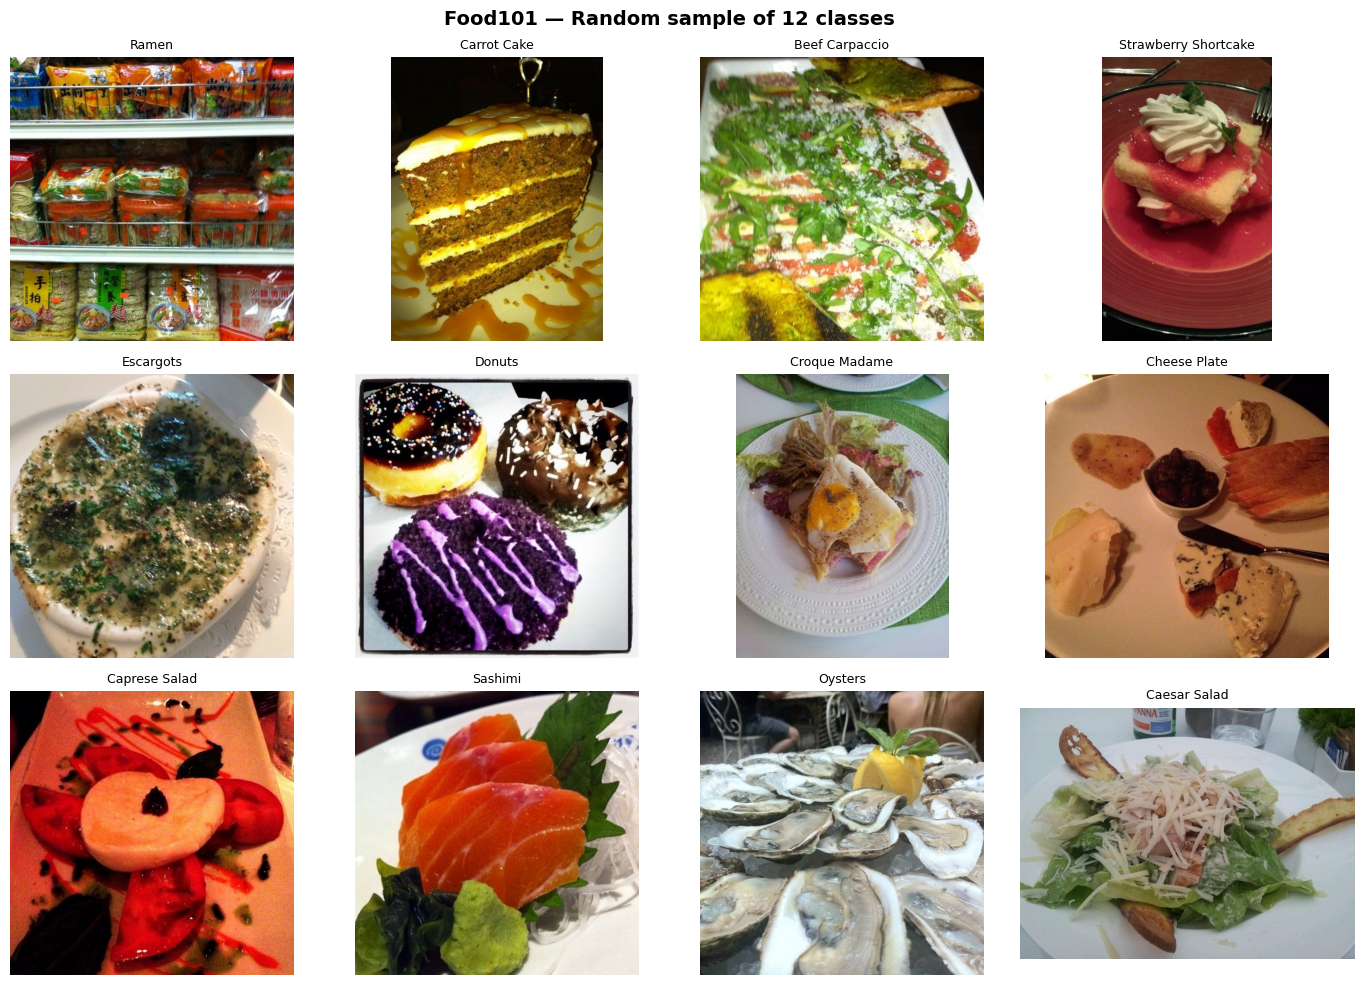

In [92]:
# ── Visual sample of the dataset ───────────────────────────────────────────────
sample_classes = random.sample(classes, 12)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, cls in zip(axes.flatten(), sample_classes):
    img_path = IMG_DIR / cls
    img_file = random.choice(list(img_path.glob("*.jpg")))
    img = mpimg.imread(img_file)
    ax.imshow(img)
    ax.set_title(cls.replace("_", " ").title(), fontsize=9)
    ax.axis("off")

plt.suptitle("Food101 — Random sample of 12 classes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 2 · Data Splitting & DataLoaders

The Food101 dataset provides official **train** and **test** splits via `meta/train.txt` and `meta/test.txt`. We further carve a **validation set** out of the official training split using an 80/20 stratified split.

| Split | Source | Purpose |
|---|---|---|
| Train | 80 % of official train | Optimise model weights |
| Validation | 20 % of official train | Tune hyper-parameters, early stopping |
| Test | Official test split | Final unbiased evaluation |

**Data augmentation** is applied only to the training set to improve generalisation.

In [93]:
# ── Transforms ─────────────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# train_transform = transforms.Compose([
#     transforms.Resize((IMG_SIZE, IMG_SIZE)),
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomRotation(15),
#     transforms.ToTensor(),
#     transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
# ])

# test_transform = transforms.Compose([
#     transforms.Resize((IMG_SIZE, IMG_SIZE)),
#     transforms.ToTensor(),
#     transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
# ])



train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)), # Better than just Resize
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# For testing, you want to resize the shortest edge, then center crop
test_transform = transforms.Compose([
    transforms.Resize(256), 
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [94]:
full_train_dataset = datasets.ImageFolder(root=IMG_DIR, transform=train_transform)
full_test_dataset  = datasets.ImageFolder(root=IMG_DIR, transform=test_transform)

In [95]:
# ── 2. Read the official split files ───────────────────────────────────────────
def read_split_file(filepath):
    with open(filepath, 'r') as f:
        # Returns a set of strings like {"apple_pie/1005649", "churros/1004234"}
        return set(line.strip() for line in f.readlines())

train_keys = read_split_file(META_DIR / "train.txt")
test_keys  = read_split_file(META_DIR / "test.txt")


train_indices = []
test_indices  = []

print("Mapping splits to dataset indices...")
for idx, (file_path, _) in enumerate(full_train_dataset.samples):
    # Extract "class_name/file_name" without the .jpg extension
    # e.g., from "/content/food-101/images/churros/1004234.jpg" -> "churros/1004234"
    path_obj = Path(file_path)
    key = f"{path_obj.parent.name}/{path_obj.stem}"
    
    if key in train_keys:
        train_indices.append(idx)
    elif key in test_keys:
        test_indices.append(idx)
        

print("First 10 train indices:", train_indices[:10], "| len:", len(train_indices))
print("First 10 test indices:", test_indices[:10], "| len:", len(test_indices))

Mapping splits to dataset indices...
First 10 train indices: [0, 3, 4, 5, 9, 11, 12, 13, 15, 16] | len: 75749
First 10 test indices: [1, 2, 6, 7, 8, 10, 14, 23, 25, 30] | len: 25250


In [96]:
random.seed(SEED)
random.shuffle(train_indices)

In [97]:
val_size = int(VAL_FRACTION * len(train_indices))

val_indices   = train_indices[:val_size]
train_indices = train_indices[val_size:]

train_dataset = Subset(full_train_dataset, train_indices)

val_dataset   = Subset(full_test_dataset, val_indices)
test_dataset  = Subset(full_test_dataset, test_indices)

print(f"Train samples : {len(train_dataset)}")
print(f"Val   samples : {len(val_dataset)}")
print(f"Test  samples : {len(test_dataset)}")

Train samples : 64387
Val   samples : 11362
Test  samples : 25250


In [98]:
# ── DataLoaders ────────────────────────────────────────────────────────────────
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=NUM_WORKERS,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=NUM_WORKERS,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(f"Train batches : {len(train_loader):>3} | Batch size: {train_loader.batch_size}")
print(f"Val   batches : {len(val_loader):>3} | Batch size: {val_loader.batch_size}")
print(f"Test  batches : {len(test_loader):>3} | Batch size: {test_loader.batch_size}")
print("-" * 50)

Train batches : 1007 | Batch size: 64
Val   batches : 178 | Batch size: 64
Test  batches : 395 | Batch size: 64
--------------------------------------------------


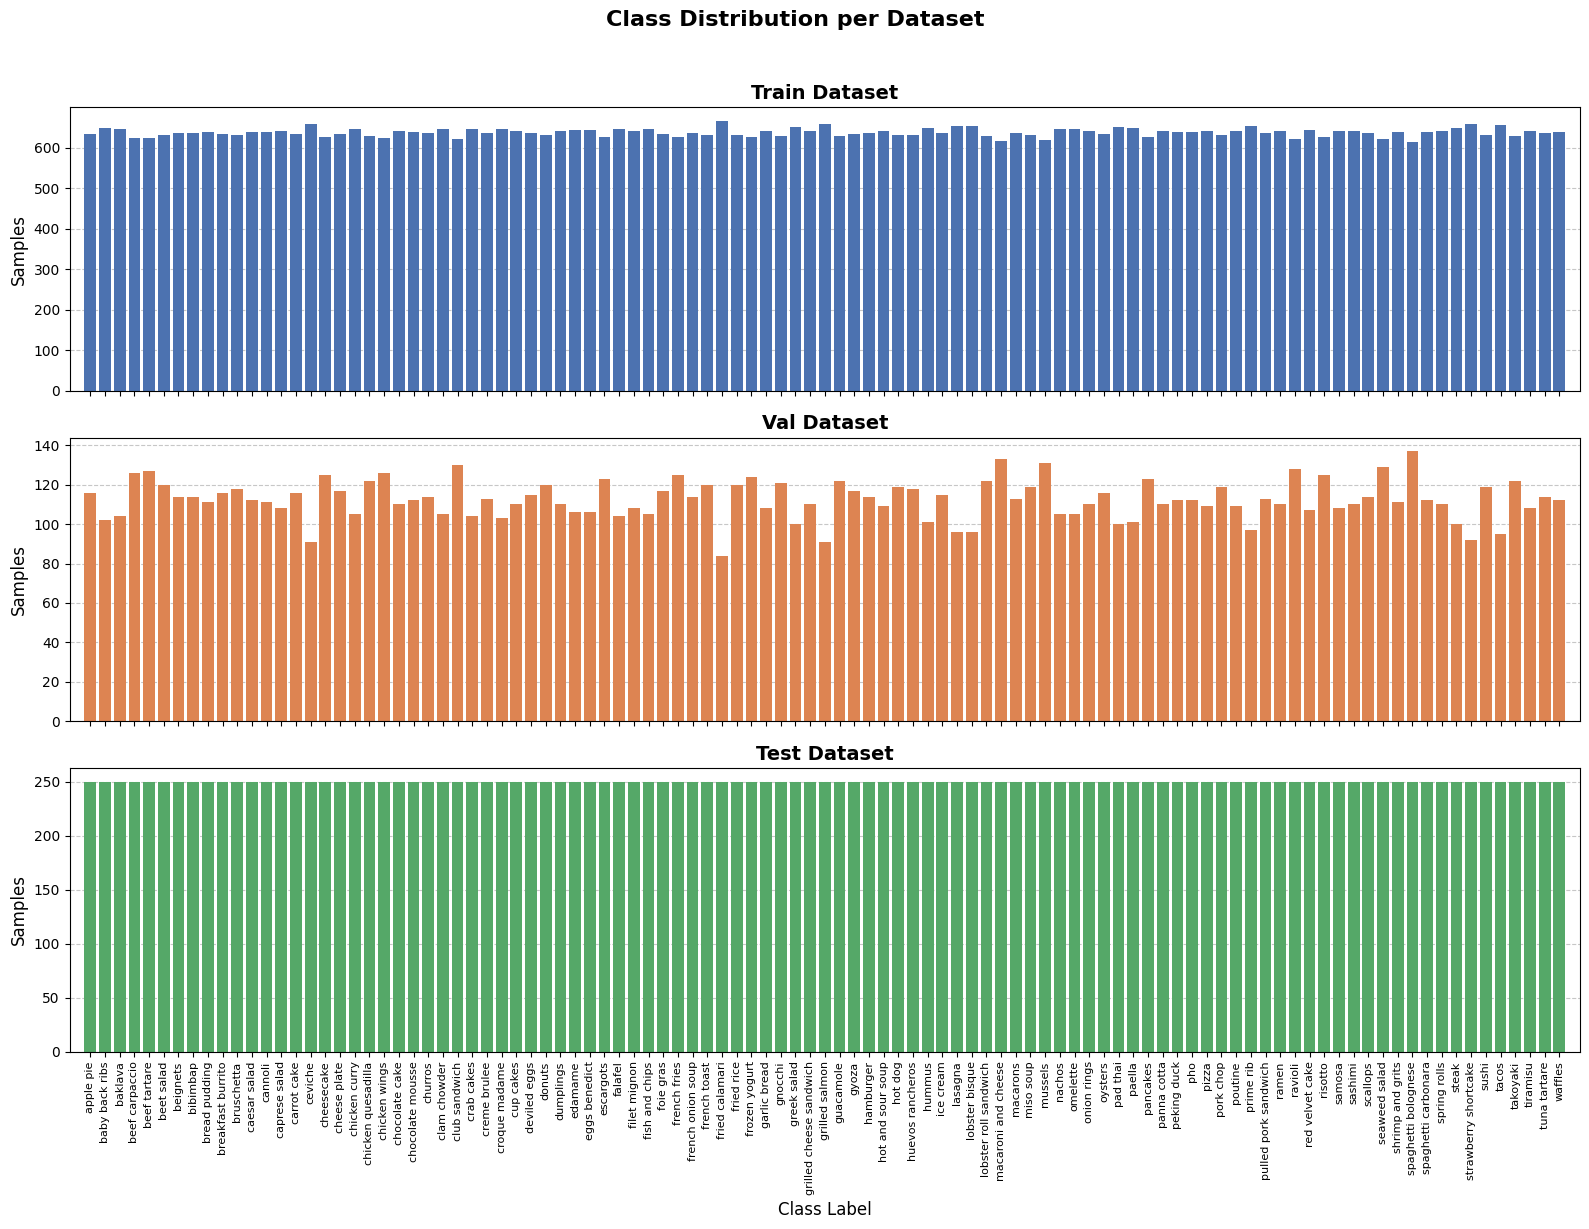

In [99]:
visualizer.plot_class_distribution(
    datasets_dict={
        "Train": train_dataset,
        "Val": val_dataset,
        "Test": test_dataset
    },
    class_names=classes
)

---
## 3 · Model Architecture

### Custom Classification Head

For each model the original classification head is replaced with a **three-layer MLP** following the assignment specification:

```
backbone_out_features → 512 → 256 → 101
     (frozen)           FC     FC    FC (output)
                        ReLU   ReLU
                        Dropout Dropout
```

All backbone parameters are **frozen** (`requires_grad = False`); only the new head is trained.

### Architecture Overviews

| Property | GoogLeNet | MobileNet V3 | ResNet-50 |
|---|---|---|---|
| Depth | 22 layers | 48 layers | 50 layers |
| Params (full) | ~6.8 M | ~5.4 M | ~25.6 M |
| Backbone output | 1024 | 960 | 2048 |
| Key feature | Inception modules | Inverted residuals + SE | Residual connections |

In [100]:
def build_custom_head(in_features: int, num_classes: int = 101) -> nn.Sequential:
    """Three fully-connected layer head as required by the assignment."""
    return nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(512, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )

def freeze_backbone(model: nn.Module) -> None:
    """Freeze all parameters; new head layers will be unfrozen separately."""
    for param in model.parameters():
        param.requires_grad = False


def count_params(model: nn.Module):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

In [101]:
# ── GoogLeNet ──────────────────────────────────────────────────────────────────
googlenet = models.googlenet(weights=models.GoogLeNet_Weights.IMAGENET1K_V1)

# 1. Print the original FC layer
print("--- Original GoogLeNet FC ---")
print(googlenet.fc)
print()

freeze_backbone(googlenet)
googlenet.fc = build_custom_head(googlenet.fc.in_features)  # replace head (unfrozen by default)

# 2. Print the updated FC layer
print("--- Updated GoogLeNet FC ---")
print(googlenet.fc)
print()

googlenet.aux_logits = False  # disable auxiliary classifiers during transfer
googlenet = googlenet.to(DEVICE)

total, trainable = count_params(googlenet)
print(f"GoogLeNet  — total params: {total:,}  |  trainable: {trainable:,}")

--- Original GoogLeNet FC ---
Linear(in_features=1024, out_features=1000, bias=True)

--- Updated GoogLeNet FC ---
Sequential(
  (0): Linear(in_features=1024, out_features=512, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=256, out_features=101, bias=True)
)

GoogLeNet  — total params: 6,281,989  |  trainable: 682,085


In [102]:
# ── MobileNet V3 Large ─────────────────────────────────────────────────────────
mobilenet = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)

# 1. Print the original classifier
print("--- Original MobileNetV3 Classifier ---")
print(mobilenet.classifier)
print()

freeze_backbone(mobilenet)
# MobileNetV3 classifier is: [Linear(960,1280), Hardswish, Dropout, Linear(1280,1000)]
in_features_mob = mobilenet.classifier[0].in_features
mobilenet.classifier = build_custom_head(in_features_mob)

# 2. Print the updated classifier
print("--- Updated MobileNetV3 Classifier ---")
print(mobilenet.classifier)
print()

mobilenet = mobilenet.to(DEVICE)

total, trainable = count_params(mobilenet)
print(f"MobileNetV3 — total params: {total:,}  |  trainable: {trainable:,}")

--- Original MobileNetV3 Classifier ---
Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=1000, bias=True)
)

--- Updated MobileNetV3 Classifier ---
Sequential(
  (0): Linear(in_features=960, out_features=512, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=256, out_features=101, bias=True)
)

MobileNetV3 — total params: 3,621,269  |  trainable: 649,317


In [103]:
# ── ResNet-50 ──────────────────────────────────────────────────────────────────
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# 1. Print the original FC layer
print("--- Original ResNet-50 FC ---")
print(resnet.fc)
print()

freeze_backbone(resnet)
resnet.fc = build_custom_head(resnet.fc.in_features)

# 2. Print the updated FC layer
print("--- Updated ResNet-50 FC ---")
print(resnet.fc)
print()

resnet = resnet.to(DEVICE)

total, trainable = count_params(resnet)
print(f"ResNet-50  — total params: {total:,}  |  trainable: {trainable:,}")

--- Original ResNet-50 FC ---
Linear(in_features=2048, out_features=1000, bias=True)

--- Updated ResNet-50 FC ---
Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=256, out_features=101, bias=True)
)

ResNet-50  — total params: 24,714,405  |  trainable: 1,206,373


---
## 4 · Training

Each model is trained independently using:
- **Loss function**: Cross-Entropy (standard for multi-class classification)
- **Optimiser**: Adam with `lr=1e-3`
- **LR scheduler**: ReduceLROnPlateau — halves the LR when validation loss stagnates
- **Metrics tracked per epoch**: training loss, validation loss, training accuracy, validation accuracy

In [104]:

from tqdm.auto import tqdm

@torch.no_grad()
def evaluate(model, loader, criterion):
    """Standalone evaluation used in section 6 (test-set scoring)."""
    use_amp = DEVICE.type == "cuda"
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    
    pbar = tqdm(
        loader, 
        leave=False, 
        desc="🧪 Evaluating", 
        colour="#00ff00",
        bar_format="{desc} |{bar:30}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]"
    )

    for images, labels in pbar:
        images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)
            
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    avg_loss = running_loss / total
    avg_acc = correct / total
    return avg_loss, avg_acc


def train_model(model, model_name, train_loader, val_loader, epochs=NUM_EPOCHS, early_stop_patience=3):
    criterion = nn.CrossEntropyLoss()
    optimiser = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode="min", factor=0.5, patience=2)

    use_amp = DEVICE.type == "cuda"
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0

    # ── Ignite trainer engine ──────────────────────────────────────────────────
    def _train_step(engine, batch):
        model.train()
        images, labels = batch
        images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        optimiser.zero_grad()
        
        with torch.amp.autocast(device_type=DEVICE.type, enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimiser)
        scaler.update()

        # Accumulate metrics
        engine.state.train_loss_sum = getattr(engine.state, "train_loss_sum", 0.0) + loss.item() * images.size(0)
        engine.state.train_correct  = getattr(engine.state, "train_correct",  0)   + outputs.argmax(1).eq(labels).sum().item()
        engine.state.train_total    = getattr(engine.state, "train_total",    0)   + labels.size(0)
        return outputs, labels

    # ── Ignite evaluator engine ────────────────────────────────────────────────
    def _eval_step(engine, batch):
        model.eval()
        with torch.no_grad():
            images, labels = batch
            images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            with torch.amp.autocast(device_type=DEVICE.type, enabled=use_amp):
                outputs = model(images)
            return outputs, labels

    trainer   = Engine(_train_step)
    evaluator = Engine(_eval_step)

    IgniteLoss(criterion).attach(evaluator, "val_loss")
    Accuracy().attach(evaluator, "val_acc")

    # 🌟 CLEAN PROGRESS BAR 🌟
    trainer_pbar = ProgressBar(
        persist=False, 
        bar_format="Training |{bar:40}| {percentage:3.0f}% [{elapsed}<{remaining}]"
    )
    trainer_pbar.attach(trainer)

    def score_function(engine):
        return -engine.state.metrics["val_loss"]

    early_stop_handler = EarlyStopping(
        patience=early_stop_patience,
        score_function=score_function,
        trainer=trainer,
    )
    evaluator.add_event_handler(Events.COMPLETED, early_stop_handler)

    print(f"\n🚀 Training: {model_name} | Device: {DEVICE} (AMP={use_amp})")

    @trainer.on(Events.EPOCH_STARTED)
    def _reset_train_metrics(engine):
        engine.state.train_loss_sum = 0.0
        engine.state.train_correct  = 0
        engine.state.train_total    = 0

    @trainer.on(Events.EPOCH_COMPLETED)
    def _on_epoch_end(engine):
        nonlocal best_val_acc
        epoch = engine.state.epoch
        
        tr_loss = engine.state.train_loss_sum / engine.state.train_total
        tr_acc  = engine.state.train_correct  / engine.state.train_total

        evaluator.run(val_loader)
        val_loss = evaluator.state.metrics["val_loss"]
        val_acc  = evaluator.state.metrics["val_acc"]

        scheduler.step(val_loss)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(val_acc)

        best_status = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_path = CHECKPOINT_DIR / f"{model_name}_best.pth"
            torch.save(model.state_dict(), best_path)
            best_status = "⭐ NEW BEST"

        torch.save(
            {
                "epoch": epoch,
                "model_name": model_name,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimiser.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_val_acc": best_val_acc,
                "history": {k: list(v) for k, v in history.items()},
            },
            CHECKPOINT_DIR / f"{model_name}_checkpoint_last.pt",
        )
        
        # 🌟 FIX APPLIED HERE: Use Ignite's logger instead of standard print 🌟
        trainer_pbar.log_message(
            f"Epoch {epoch:>2}/{epochs} ─ "
            f"Tr Loss: {tr_loss:.4f} | Tr Acc: {tr_acc:.4f} ── "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} {best_status}"
        )

    trainer.run(train_loader, max_epochs=epochs)

    best_path = CHECKPOINT_DIR / f"{model_name}_best.pth"
    if best_path.exists():
        model.load_state_dict(torch.load(best_path, map_location=DEVICE))

    return history

### Training: GoogLeNet (Inception v1)

Classic 2014 architecture with **Inception modules** (multi-scale parallel convolutions). Here the backbone is frozen and only the custom 3-layer head learns Food101-specific features. Expect moderate parameter count and solid baseline accuracy.

In [ ]:
history_googlenet = train_model(googlenet,  "googlenet",  train_loader, val_loader)


🚀 Training: googlenet | Device: mps (AMP=False)


Training |                                        |   0% [00:00<?]

Epoch  1/12 ─ Tr Loss: 3.7064 | Tr Acc: 0.1343 ── Val Loss: 3.0254 | Val Acc: 0.2576 ⭐ NEW BEST


Training |                                        |   0% [00:00<?]

In [62]:
history_googlenet = train_model(googlenet,  "googlenet",  train_loader, val_loader)


🚀 Training: googlenet | Device: mps (AMP=False)


Training |                                        |   0% [00:00<?]

Epoch  1/12 ─ Tr Loss: 3.6224 | Tr Acc: 0.1498 ── Val Loss: 2.9250 | Val Acc: 0.2831 ⭐ NEW BEST


Training |                                        |   0% [00:00<?]

Epoch  2/12 ─ Tr Loss: 3.0792 | Tr Acc: 0.2525 ── Val Loss: 2.7234 | Val Acc: 0.3266 ⭐ NEW BEST


...

Training |                                        |   0% [00:00<?]

Epoch  9/12 ─ Tr Loss: 2.8073 | Tr Acc: 0.3163 ── Val Loss: 2.4944 | Val Acc: 0.3800 


Training |                                        |   0% [00:00<?]

2026-04-08 19:29:02,703 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


Epoch 10/12 ─ Tr Loss: 2.7999 | Tr Acc: 0.3178 ── Val Loss: 2.4676 | Val Acc: 0.3928 


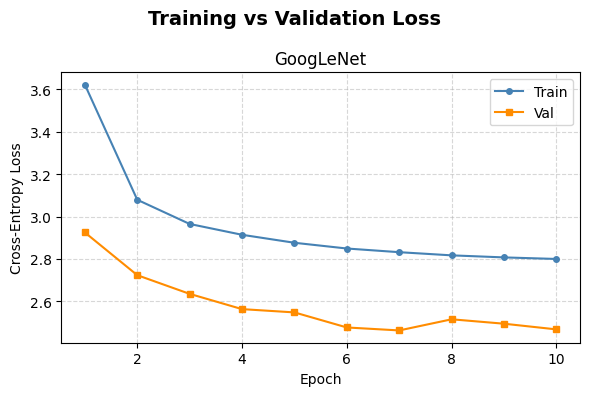

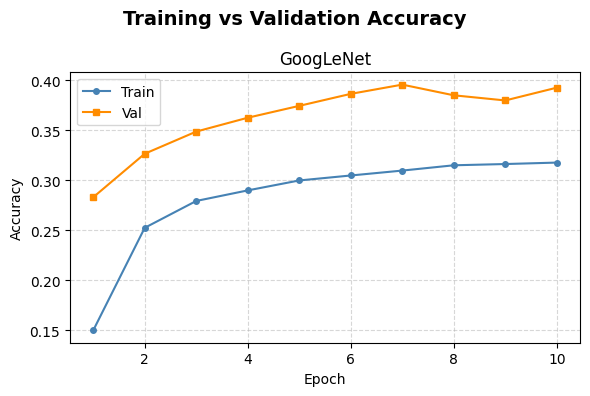

In [63]:
visualizer.plot_loss({"GoogLeNet": history_googlenet})
visualizer.plot_accuracy({"GoogLeNet": history_googlenet})

In [ ]:
visualizer.plot_confusion_matrix(googlenet, test_loader, classes, top_n=20)

### Training: MobileNet V3 Large

**Depthwise separable convolutions** and inverted residuals keep this model lightweight while the large variant stays expressive enough for fine-grained food classes. Training updates only the new head; the backbone supplies mobile-optimised ImageNet features.

In [33]:
history_mobilenet = train_model(mobilenet, "mobilenet", train_loader, val_loader)


🚀 Training: mobilenet | Device: mps (AMP=False)


Training |1                                       |   0% [00:00<?]

Epoch  1/15 ─ Tr Loss: 2.8665 | Tr Acc: 0.3093 ── Val Loss: 2.0822 | Val Acc: 0.4778 ⭐ NEW BEST


Training |1                                       |   0% [00:00<?]

Epoch  2/15 ─ Tr Loss: 2.1694 | Tr Acc: 0.4511 ── Val Loss: 1.8928 | Val Acc: 0.5217 ⭐ NEW BEST


...

Training |1                                       |   0% [00:00<?]

Epoch  4/15 ─ Tr Loss: 1.9310 | Tr Acc: 0.5051 ── Val Loss: 1.7641 | Val Acc: 0.5489 ⭐ NEW BEST


Training |1                                       |   0% [00:00<?]

Engine run is terminating due to exception: 


KeyboardInterrupt: 

In [ ]:
visualizer.plot_loss({"MobileNetV3": history_mobilenet})
visualizer.plot_accuracy({"MobileNetV3": history_mobilenet})

In [ ]:
visualizer.plot_confusion_matrix(mobilenet, test_loader, classes, top_n=20)

### Training: ResNet-50

**Residual skip connections** ease optimisation in deep networks. ResNet-50 provides a 2048-D feature map before the head; it often leads the pack in frozen-backbone transfer on challenging classification tasks.

In [65]:
history_resnet = train_model(resnet, "resnet", train_loader, val_loader)


🚀 Training: resnet | Device: mps (AMP=False)


Training |                                        |   0% [00:00<?]

Epoch  1/12 ─ Tr Loss: 3.4539 | Tr Acc: 0.1766 ── Val Loss: 2.6168 | Val Acc: 0.3475 ⭐ NEW BEST


Training |                                        |   0% [00:00<?]

Epoch  2/12 ─ Tr Loss: 2.8281 | Tr Acc: 0.2970 ── Val Loss: 2.4593 | Val Acc: 0.3840 ⭐ NEW BEST


...

Epoch 10/12 ─ Tr Loss: 2.5126 | Tr Acc: 0.3720 ── Val Loss: 2.1845 | Val Acc: 0.4524 


Training |                                        |   0% [00:00<?]

Epoch 11/12 ─ Tr Loss: 2.4986 | Tr Acc: 0.3741 ── Val Loss: 2.1243 | Val Acc: 0.4685 ⭐ NEW BEST


Training |                                        |   0% [00:00<?]

Epoch 12/12 ─ Tr Loss: 2.4949 | Tr Acc: 0.3738 ── Val Loss: 2.1480 | Val Acc: 0.4659 


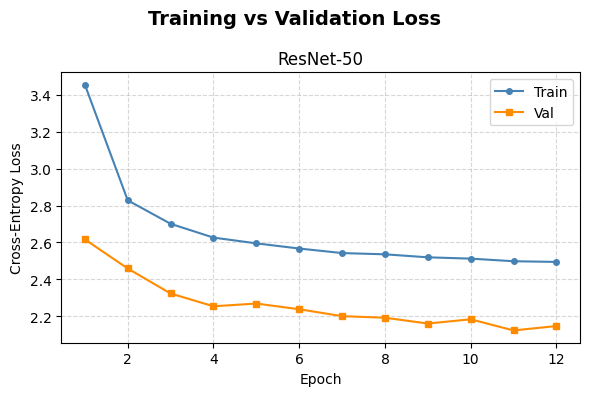

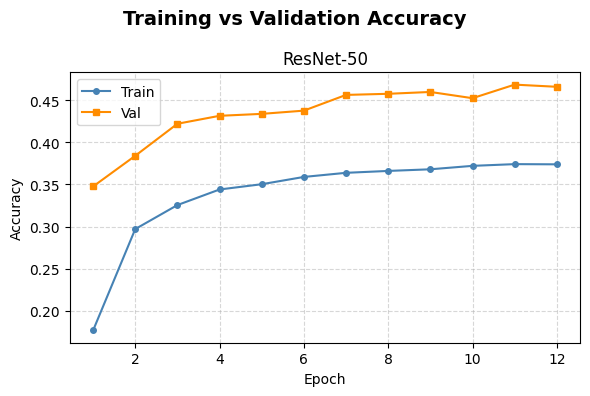

In [66]:
visualizer.plot_loss({"ResNet-50": history_resnet})
visualizer.plot_accuracy({"ResNet-50": history_resnet})

In [ ]:
visualizer.plot_confusion_matrix(resnet, test_loader, classes, top_n=20)

---
## 5 · Training Curves — Loss & Accuracy

The plots below show **training and validation loss/accuracy over each epoch** for all three models, enabling side-by-side comparison.

In [ ]:
all_histories = {
    "GoogLeNet":   history_googlenet,
    "MobileNetV3": history_mobilenet,
    "ResNet-50":   history_resnet,
}

visualizer.plot_loss(all_histories)
visualizer.plot_accuracy(all_histories)


In [ ]:
# ── Overlay comparison: val accuracy across all models ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {"GoogLeNet": "royalblue", "MobileNetV3": "mediumseagreen", "ResNet-50": "tomato"}

for name, hist in all_histories.items():
    n_epochs = len(hist["val_loss"])
    epochs = range(1, n_epochs + 1)
    axes[0].plot(epochs, hist["val_loss"], label=name, color=palette[name], marker="o", ms=4)
    axes[1].plot(epochs, hist["val_acc"],  label=name, color=palette[name], marker="o", ms=4)

for ax, title, ylabel in zip(
    axes,
    ["Validation Loss Comparison", "Validation Accuracy Comparison"],
    ["Cross-Entropy Loss", "Accuracy"],
):
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

plt.suptitle("All Models — Validation Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


---
## 6 · Test Set Evaluation

Each model is loaded with its **best checkpoint** from the `checkpoints/` folder (`{model}_best.pth`, highest validation accuracy) and evaluated on the held-out test set.

In [ ]:
visualizer.plot_test_accuracy(results)
visualizer.plot_test_loss(results)


In [ ]:
criterion = nn.CrossEntropyLoss()

results = {}
for name, model in [("GoogLeNet", googlenet), ("MobileNetV3", mobilenet), ("ResNet-50", resnet)]:
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    # Retrieve best_val_acc from checkpoint
    ckpt_path = CHECKPOINT_DIR / f"{name.lower().replace('-', '').replace(' ', '')}_checkpoint_last.pt"
    best_val_acc = 0.0
    _name_map = {"GoogLeNet": "googlenet", "MobileNetV3": "mobilenet", "ResNet-50": "resnet"}
    ckpt_path = CHECKPOINT_DIR / f"{_name_map[name]}_checkpoint_last.pt"
    if ckpt_path.exists():
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        best_val_acc = ckpt.get("best_val_acc", 0.0)
    results[name] = {"test_loss": test_loss, "test_acc": test_acc, "best_val_acc": best_val_acc}
    print(f"{name:12s}  test_loss={test_loss:.4f}  test_acc={test_acc:.4f}")

# Add dummy baseline
results["Dummy"] = {"test_loss": None, "test_acc": dummy_test_acc, "best_val_acc": dummy_test_acc}

In [ ]:
# ── Confusion matrices for each model (top-20 most-confused classes) ───────────
for name, model in [("GoogLeNet", googlenet), ("MobileNetV3", mobilenet), ("ResNet-50", resnet)]:
    print(f"\n{name}")
    visualizer.plot_confusion_matrix(model, test_loader, classes, top_n=20)

In [ ]:
# ── Bar chart: test accuracy comparison ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
model_names = list(results.keys())
test_accs   = [results[m]["test_acc"] for m in model_names]
colours     = ["royalblue", "mediumseagreen", "tomato", "silver"]

bars = ax.bar(model_names, test_accs, color=colours, edgecolor="white", linewidth=1.2)
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Test Accuracy", fontsize=12)
ax.set_title("Test Accuracy — Transfer Learning vs Dummy Baseline", fontsize=14, fontweight="bold")
ax.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
## 7 · Summary & Conclusions

The table below summarises the results of transfer learning across all three architectures:


In [ ]:
summary_df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})
summary_df["test_acc_%"]     = (summary_df["test_acc"]     * 100).round(2)
summary_df["best_val_acc_%"] = (summary_df["best_val_acc"] * 100).round(2)
display(summary_df[["Model", "best_val_acc_%", "test_acc_%", "test_loss"]])

best_model = summary_df.loc[summary_df["test_acc"].idxmax(), "Model"]
print(f"\nBest model for Part B fine-tuning: {best_model}")

### Key Observations

- **GoogLeNet** uses Inception modules with parallel convolution branches (1×1, 3×3, 5×5) enabling efficient multi-scale feature extraction at relatively low parameter cost.
- **MobileNetV3** is the most parameter-efficient model, using depthwise separable convolutions and Squeeze-and-Excitation blocks. Despite fewer parameters, it often achieves competitive accuracy, making it suitable for mobile/edge deployment.
- **ResNet-50** benefits from residual (skip) connections that enable very deep networks to train effectively. With 2048-dimensional features from its backbone, it typically achieves the strongest transfer learning performance.
- Only the **custom 3-layer head** was trained in this experiment — the frozen backbone already provides powerful general-purpose visual features from ImageNet pretraining.
- The best-performing model above will be selected for **Part B fine-tuning**, where selected backbone layers will be progressively unfrozen.

---
*End of Part A*